In [3]:
# import Required libraries

import os,random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from sklearn.preprocessing import MinMaxScaler
import warnings


In [4]:
# Load the dataset

df = pd.read_csv("Bitcoin Historical Data .csv")
print("Shape of the dataset:", df.shape)

Shape of the dataset: (4999, 7)


In [5]:
np.random.seed(42)                                                                     # makes the random repeatable.(for this we can get the same output every time we run the code)
dates = pd.date_range(start="2015-01-01", end="2024-12-31", freq="D")                  # it sets the date range (min to max)
n = len(dates)                                                                         # calculate the number of days in the date range

price = 200 + np.cumsum(np.random.randn(n) * 300)                                      # create the simulated price data using a random daily movement. np.cumsum() makes the data cumulative.
price = np.abs(price)                                                                  # Converts any negative prices into positive values.
df = pd.DataFrame({                                                                    # Creates a Pandas DataFrame using all these generated values.
    "Date":     dates,                                                                 # date
    "Price":    np.round(price, 2),                                                    # simulated closing price data rounded to 2 decimal places.
    "Open":     np.round(price * (1 + np.random.uniform(-0.01, 0.01, n)), 2),          # simulated opening price data.
    "High":     np.round(price * (1 + np.random.uniform(0.00,  0.02, n)), 2),          # simulated highest price data.
    "Low":      np.round(price * (1 - np.random.uniform(0.00,  0.02, n)), 2),          # simulated lowest price data.
    "Vol.":     np.round(np.random.uniform(1e9, 5e10, n), 0),                          # simulated trading volume data.
    "Change %": np.round(np.random.uniform(-5, 5, n), 2),                              # simulated percentage change data.
}) # Creates a Pandas DataFrame using all these generated values.

In [6]:
# colum name vol. to convert volume

df=df.rename(columns={"Vol.": "Volume"})

In [7]:
#missing_data = np.random.choice(n, size=15, replace=False)
#df.loc[missing_data, "Price"] = np.nan

#print(f"Total rows : {len(df)}")
#df.head()

In [8]:
# sort by date

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(f"First Date : {df['Date'].min().date()}")
print(f"Last Date  : {df['Date'].max().date()}")
print(f"Total Days : {len(df)}")


First Date : 2015-01-01
Last Date  : 2024-12-31
Total Days : 3653


In [9]:
# price column has missing values. it was filled by previous value
# Forward fill -> previous day price filled with the empty columns

df["Price"] = df["Price"].ffill()

print(df.isnull().sum())

Date        0
Price       0
Open        0
High        0
Low         0
Volume      0
Change %    0
dtype: int64


In [10]:
#ensure the columns name changed
df.columns

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Volume', 'Change %'], dtype='object')

In [11]:
# feature devition / scaler section

FEATURE_COLS = ["Price","Open","High","Low","Volume","Change %"]
scaler       = MinMaxScaler()
scaled_data  = scaler.fit_transform(df[FEATURE_COLS])
price_scaler = MinMaxScaler()
price_scaler.fit(df[["Price"]])

#train and test spliting section

TRAIN_RATIO = 0.80
split_idx   = int(len(scaled_data) * TRAIN_RATIO)
train_data  = scaled_data[:split_idx]
test_data   = scaled_data[split_idx:]

In [12]:
#sequence creating
WINDOW = 60

def create_sequences(data, window=60, horizon=1):
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i : i + window])
        y.append(data[i + window : i + window + horizon, 0])
    return np.array(X), np.array(y)

X_tr1,y_tr1 = create_sequences(train_data, WINDOW, 1)
X_te1,y_te1 = create_sequences(test_data,  WINDOW, 1)
X_tr3,y_tr3 = create_sequences(train_data, WINDOW, 3)
X_te3,y_te3 = create_sequences(test_data,  WINDOW, 3)
X_tr7,y_tr7 = create_sequences(train_data, WINDOW, 7)
X_te7,y_te7 = create_sequences(test_data,  WINDOW, 7)

N_FEAT = X_tr1.shape[2]   # 6

print(" (Data ready)")
print(f"   Train samples (1-Day) : {len(X_tr1):,}   shape: {X_tr1.shape}")
print(f"   Test  samples (1-Day) : {len(X_te1):,}    shape: {X_te1.shape}")
print(f"   Features per timestep : {N_FEAT}")


 (Data ready)
   Train samples (1-Day) : 2,862   shape: (2862, 60, 6)
   Test  samples (1-Day) : 671    shape: (671, 60, 6)
   Features per timestep : 6


In [13]:
# Reshape

def verify_shapes(X_train, y_train, X_test, y_test, horizon_name):
    """Shape validation with assertion checks."""
    n_features = X_train.shape[2]
    window     = X_train.shape[1]

    # if wrong shapes is there it will alert imediatly
    assert X_train.ndim == 3,          "X_train 3D"
    assert X_test.ndim  == 3,          "X_test 3D "

    assert X_train.shape[1] == WINDOW, f"Window {WINDOW}"
    assert X_train.shape[2] == X_test.shape[2], "Feature count match "
    assert y_train.shape[1] == y_test.shape[1], "Horizon count match "

    h = y_train.shape[1]
    print(f"  {horizon_name} ")
    print(f"    X_train : {X_train.shape}  "
          f"→ {X_train.shape[0]:,} samples × {window} days × {n_features} features")
    print(f"    y_train : {y_train.shape}  "
          f"→ {y_train.shape[0]:,} samples × {h} target day(s)")
    print(f"    X_test  : {X_test.shape}   "
          f"→ {X_test.shape[0]:,} samples")
    print(f"    y_test  : {y_test.shape}   "
          f"→ {y_test.shape[0]:,} samples")
    print()

print("Shape Verification:")
print("═" * 55)
verify_shapes(X_tr1, y_tr1, X_te1, y_te1, "1-Day Horizon")
verify_shapes(X_tr3, y_tr3, X_te3, y_te3, "3-Day Horizon")
verify_shapes(X_tr7, y_tr7, X_te7, y_te7, "7-Day Horizon")

print("All assertions passed!")

Shape Verification:
═══════════════════════════════════════════════════════
  1-Day Horizon 
    X_train : (2862, 60, 6)  → 2,862 samples × 60 days × 6 features
    y_train : (2862, 1)  → 2,862 samples × 1 target day(s)
    X_test  : (671, 60, 6)   → 671 samples
    y_test  : (671, 1)   → 671 samples

  3-Day Horizon 
    X_train : (2860, 60, 6)  → 2,860 samples × 60 days × 6 features
    y_train : (2860, 3)  → 2,860 samples × 3 target day(s)
    X_test  : (669, 60, 6)   → 669 samples
    y_test  : (669, 3)   → 669 samples

  7-Day Horizon 
    X_train : (2856, 60, 6)  → 2,856 samples × 60 days × 6 features
    y_train : (2856, 7)  → 2,856 samples × 7 target day(s)
    X_test  : (665, 60, 6)   → 665 samples
    y_test  : (665, 7)   → 665 samples

All assertions passed!


In [14]:
#required libraries import
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

In [15]:
os.environ["PYTHONHASHSEED"]       = "42"
os.environ["TF_ENABLE_ONEDNN_OPTS"]= "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [16]:
random.seed(42)
np.random.seed(42)

In [17]:
import tensorflow as tf
tf.random.set_seed(42)

In [18]:
# for model bulding required packages import

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models    import Sequential, Model
from tensorflow.keras.layers    import (
    SimpleRNN, LSTM, Conv1D, MaxPooling1D, Dense, Dropout,
    Flatten, MultiHeadAttention, LayerNormalization,
    GlobalAveragePooling1D, Input, Add
)
from tensorflow.keras.optimizers import Adam

In [19]:
def train_model(model, X_tr, y_tr, epochs=60, batch=32, val=0.10):
    cb = [
        EarlyStopping(monitor="val_loss", patience=8,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=4, min_lr=1e-6, verbose=0),
    ]
    return model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch,
                     validation_split=val, callbacks=cb, verbose=0)

In [20]:
def compute_metrics(model, X_te, y_te, price_scaler):
    """
    Returns dict:  MAE, RMSE, MAPE, R2, y_true_usd, y_pred_usd
    All values in USD scale (inverse-transformed).
    """
    y_pred_s = model.predict(X_te, verbose=0)                         # scaled
    y_true   = price_scaler.inverse_transform(
                   y_te.reshape(-1,1)).flatten()                       # USD
    y_pred   = price_scaler.inverse_transform(
                   y_pred_s.reshape(-1,1)).flatten()                   # USD

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    errors = y_true - y_pred                                           # residuals

    return dict(MAE=mae, RMSE=rmse, MAPE=mape, R2=r2,
                y_true=y_true, y_pred=y_pred, errors=errors)

In [21]:
def plot_forecast(res, model_name, horizon_label, ax, n_show=150):
    ax.plot(res["y_true"][:n_show], label="Actual",
            color="#1a1a2e", linewidth=1.4)
    ax.plot(res["y_pred"][:n_show], label="Predicted",
            color="#e05c2e", linewidth=1.0, linestyle="--")
    ax.set_title(
        f"{model_name}  [{horizon_label}]\n"
        f"MAE=${res['MAE']:,.0f}  RMSE=${res['RMSE']:,.0f}"
        f"  MAPE={res['MAPE']:.2f}%  R²={res['R2']:.3f}",
        fontsize=8.5)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))

In [22]:
def plot_loss(hist, model_name, horizon_label, ax, color="#0d6efd"):
    ax.plot(hist.history["loss"],     color=color,   label="Train", lw=1.4)
    ax.plot(hist.history["val_loss"], color="#e05c2e",label="Val",
            linestyle="--", lw=1.2)
    ep = len(hist.history["loss"])
    ax.set_title(f"{model_name}  [{horizon_label}]  ({ep} epochs)", fontsize=9)
    ax.set_xlabel("Epochs"); ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.25)

MODEL 1 -- RNN

In [23]:
def build_rnn(window, n_feat, horizon):
    m = Sequential([
        SimpleRNN(64, return_sequences=True,
                  input_shape=(window, n_feat), activation="tanh"),
        Dropout(0.2),
        SimpleRNN(32, return_sequences=False, activation="tanh"),
        Dropout(0.2),
        Dense(horizon),
    ], name=f"RNN_h{horizon}")
    m.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
    return m

In [24]:
print("RNN TRAINNG... (Training RNN for 1D / 3D / 7D)")
rnn_res = {}
for h, Xtr, ytr, Xte, yte, lbl in [
        (1,X_tr1,y_tr1,X_te1,y_te1,"1-Day"),
        (3,X_tr3,y_tr3,X_te3,y_te3,"3-Day"),
        (7,X_tr7,y_tr7,X_te7,y_te7,"7-Day")]:
    tf.random.set_seed(42)
    m    = build_rnn(WINDOW, N_FEAT, h)
    hist = train_model(m, Xtr, ytr)
    res  = compute_metrics(m, Xte, yte, price_scaler)
    res["hist"] = hist
    rnn_res[lbl] = res
    print(f"  {lbl}  MAE=${res['MAE']:,.0f}  RMSE=${res['RMSE']:,.0f}"
          f"  MAPE={res['MAPE']:.2f}%  R²={res['R2']:.3f}")

RNN TRAINNG... (Training RNN for 1D / 3D / 7D)
  1-Day  MAE=$663  RMSE=$832  MAPE=2.67%  R²=0.849
  3-Day  MAE=$477  RMSE=$600  MAPE=1.90%  R²=0.921
  7-Day  MAE=$716  RMSE=$906  MAPE=2.88%  R²=0.820


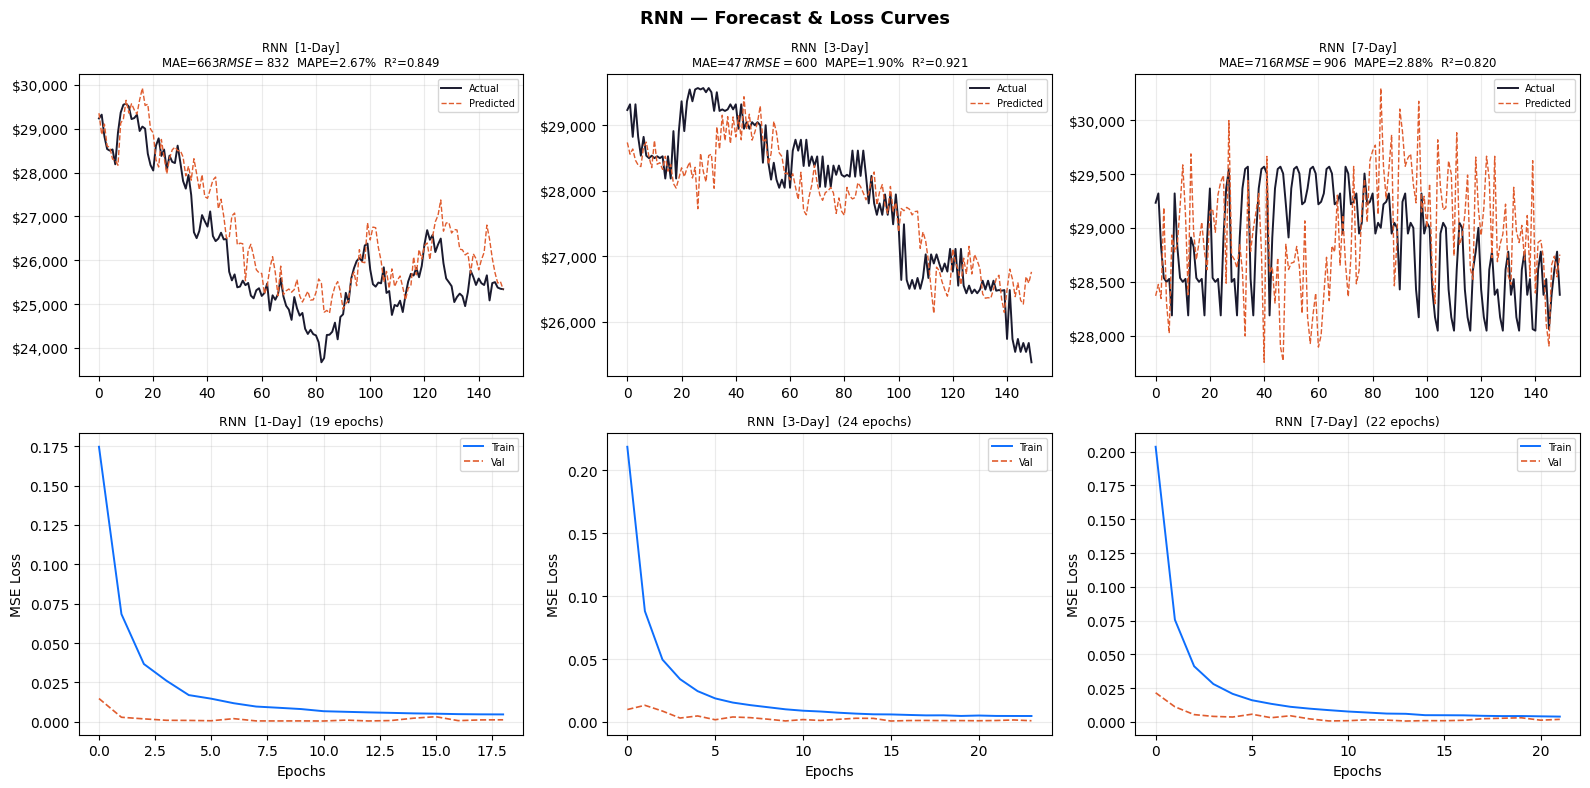

In [43]:
# RNN PLOTING

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("RNN — Forecast & Loss Curves",
             fontsize=13, fontweight="bold")
for i, lbl in enumerate(["1-Day","3-Day","7-Day"]):
    plot_forecast(rnn_res[lbl], "RNN", lbl, axes[0,i])
    plot_loss(rnn_res[lbl]["hist"], "RNN", lbl, axes[1,i], "#0d6efd")
plt.tight_layout()
plt.savefig("rnn_forecast_loss.png", dpi=150, bbox_inches="tight")
plt.show()

MODEL 2 -- LSTM

In [26]:
def build_lstm(window, n_feat, horizon):
    m = Sequential([
        LSTM(128, return_sequences=True,
             input_shape=(window, n_feat)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(horizon),
    ], name=f"LSTM_h{horizon}")
    m.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
    return m
    print("LSTM TRAINNG... (Training LSTM for 1D / 3D / 7D)")

lstm_res = {}
for h, Xtr, ytr, Xte, yte, lbl in [
        (1,X_tr1,y_tr1,X_te1,y_te1,"1-Day"),
        (3,X_tr3,y_tr3,X_te3,y_te3,"3-Day"),
        (7,X_tr7,y_tr7,X_te7,y_te7,"7-Day")]:
    tf.random.set_seed(42)
    m    = build_lstm(WINDOW, N_FEAT, h)
    hist = train_model(m, Xtr, ytr)
    res  = compute_metrics(m, Xte, yte, price_scaler)
    res["hist"] = hist
    lstm_res[lbl] = res
    print(f"  {lbl}  MAE=${res['MAE']:,.0f}  RMSE=${res['RMSE']:,.0f}"
          f"  MAPE={res['MAPE']:.2f}%  R²={res['R2']:.3f}")

print(" LSTM TRAINING IS DONE")

  1-Day  MAE=$650  RMSE=$790  MAPE=2.52%  R²=0.864
  3-Day  MAE=$509  RMSE=$643  MAPE=2.01%  R²=0.910
  7-Day  MAE=$645  RMSE=$819  MAPE=2.58%  R²=0.853
 LSTM TRAINING IS DONE


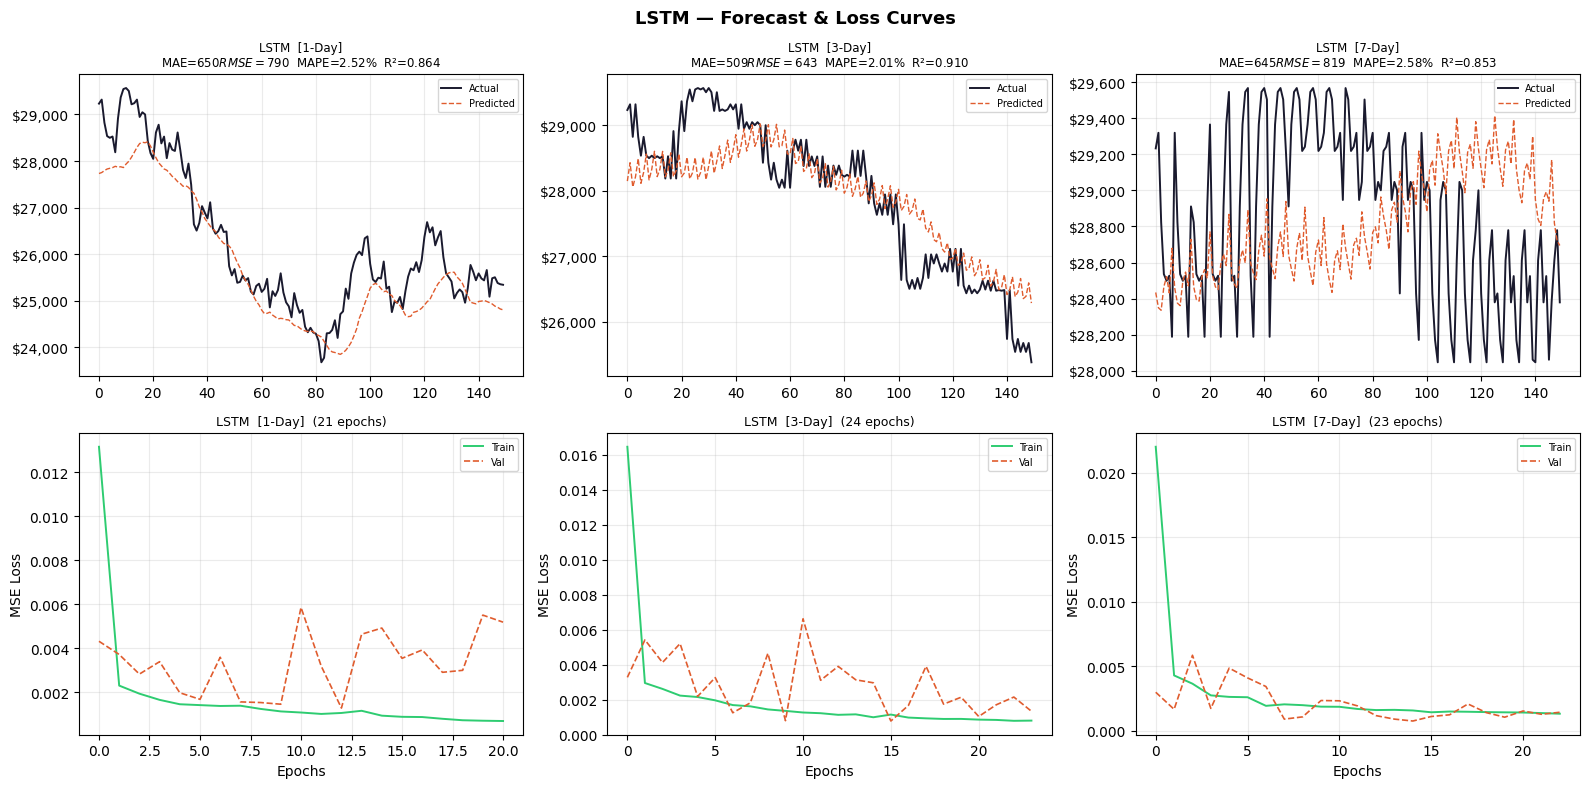

In [42]:
# LSTM ploting
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("LSTM — Forecast & Loss Curves",
             fontsize=13, fontweight="bold")
for i, lbl in enumerate(["1-Day","3-Day","7-Day"]):
    plot_forecast(lstm_res[lbl], "LSTM", lbl, axes[0,i])
    plot_loss(lstm_res[lbl]["hist"], "LSTM", lbl, axes[1,i], "#2ecc71")
plt.tight_layout()
plt.savefig("lstm_forecast_loss.png", dpi=150, bbox_inches="tight")
plt.show()

MODEL 3 CNN

In [28]:
def build_cnn(window, n_feat, horizon):
    m = Sequential([
        Conv1D(64,  kernel_size=3, activation="relu",
               padding="same", input_shape=(window, n_feat)),
        Conv1D(64,  kernel_size=3, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        Conv1D(128, kernel_size=3, activation="relu", padding="same"),
        Dropout(0.2),
        GlobalAveragePooling1D(),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(horizon),
    ], name=f"CNN_h{horizon}")
    m.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
    return m

print("(Training CNN for 1D / 3D / 7D)")
cnn_res = {}
for h, Xtr, ytr, Xte, yte, lbl in [
        (1,X_tr1,y_tr1,X_te1,y_te1,"1-Day"),
        (3,X_tr3,y_tr3,X_te3,y_te3,"3-Day"),
        (7,X_tr7,y_tr7,X_te7,y_te7,"7-Day")]:
    tf.random.set_seed(42)
    m    = build_cnn(WINDOW, N_FEAT, h)
    hist = train_model(m, Xtr, ytr, batch=64)
    res  = compute_metrics(m, Xte, yte, price_scaler)
    res["hist"] = hist
    cnn_res[lbl] = res
    print(f"  {lbl}  MAE=${res['MAE']:,.0f}  RMSE=${res['RMSE']:,.0f}"
          f"  MAPE={res['MAPE']:.2f}%  R²={res['R2']:.3f}")

print(" 1D-CNN traing is done!")

(Training CNN for 1D / 3D / 7D)
  1-Day  MAE=$1,081  RMSE=$1,478  MAPE=4.41%  R²=0.524
  3-Day  MAE=$1,083  RMSE=$1,400  MAPE=4.39%  R²=0.572
  7-Day  MAE=$1,215  RMSE=$1,666  MAPE=4.99%  R²=0.391
 1D-CNN traing is done!


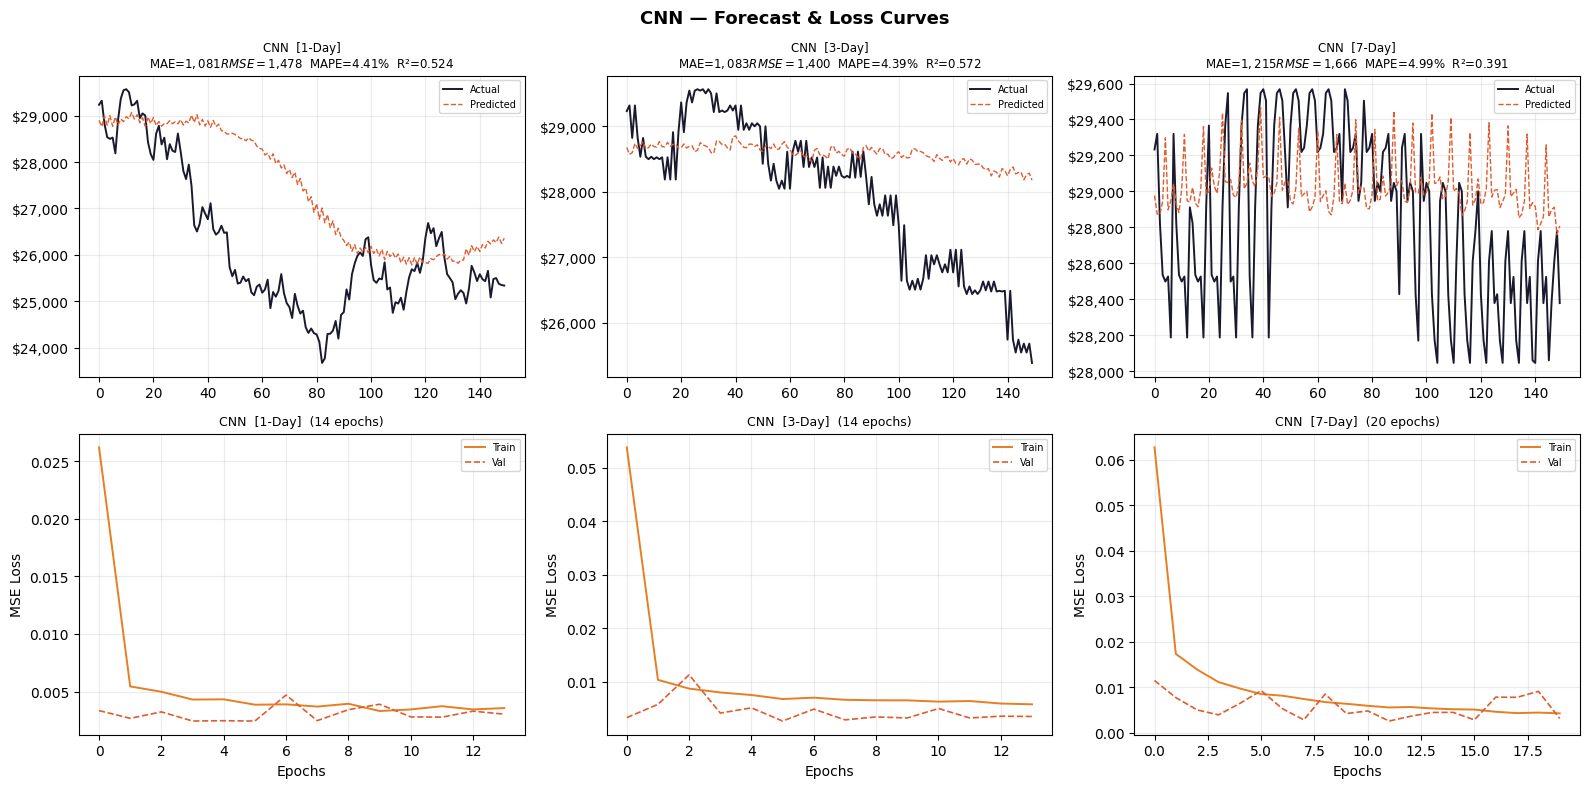

In [29]:
#CNN ploting

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("CNN — Forecast & Loss Curves",
             fontsize=13, fontweight="bold")
for i, lbl in enumerate(["1-Day","3-Day","7-Day"]):
    plot_forecast(cnn_res[lbl], "CNN", lbl, axes[0,i])
    plot_loss(cnn_res[lbl]["hist"], "CNN", lbl, axes[1,i], "#e67e22")
plt.tight_layout()
plt.savefig("cnn_forecast_loss.png", dpi=150, bbox_inches="tight")
plt.show()


MODEL 4 --Transformer (time series self attention)

In [30]:
def build_transformer(window, n_feat, horizon,
                       d_model=64, n_heads=4, ff_dim=128, drop=0.1):
    inp = Input(shape=(window, n_feat))

    # Project to d_model dimensions
    x = Dense(d_model)(inp)

    # ── Attention block ──────────────────────────────────────────
    attn = MultiHeadAttention(
        num_heads=n_heads,
        key_dim=d_model // n_heads,
        dropout=drop)(x, x)
    x = LayerNormalization(epsilon=1e-6)(Add()([x, attn]))

    # ── Feed-forward block ───────────────────────────────────────
    ff  = Dense(ff_dim, activation="relu")(x)
    ff  = Dense(d_model)(ff)
    ff  = Dropout(drop)(ff)
    x   = LayerNormalization(epsilon=1e-6)(Add()([x, ff]))

    # ── Output head ──────────────────────────────────────────────
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(64, activation="relu")(x)
    x   = Dropout(drop)(x)
    out = Dense(horizon)(x)

    m = Model(inp, out, name=f"Transformer_h{horizon}")
    m.compile(optimizer=Adam(1e-4), loss="mse", metrics=["mae"])
    return m

print("(Training Transformer for 1D / 3D / 7D)")
tfm_res = {}
for h, Xtr, ytr, Xte, yte, lbl in [
        (1,X_tr1,y_tr1,X_te1,y_te1,"1-Day"),
        (3,X_tr3,y_tr3,X_te3,y_te3,"3-Day"),
        (7,X_tr7,y_tr7,X_te7,y_te7,"7-Day")]:
    tf.random.set_seed(42)
    m    = build_transformer(WINDOW, N_FEAT, h)
    hist = train_model(m, Xtr, ytr)
    res  = compute_metrics(m, Xte, yte, price_scaler)
    res["hist"] = hist
    tfm_res[lbl] = res
    print(f"  {lbl}  MAE=${res['MAE']:,.0f}  RMSE=${res['RMSE']:,.0f}"
          f"  MAPE={res['MAPE']:.2f}%  R²={res['R2']:.3f}")

print(" Transformer training is done!")

(Training Transformer for 1D / 3D / 7D)
  1-Day  MAE=$1,448  RMSE=$2,012  MAPE=6.02%  R²=0.118
  3-Day  MAE=$1,228  RMSE=$1,560  MAPE=4.97%  R²=0.468
  7-Day  MAE=$1,201  RMSE=$1,631  MAPE=4.95%  R²=0.416
 Transformer training is done!


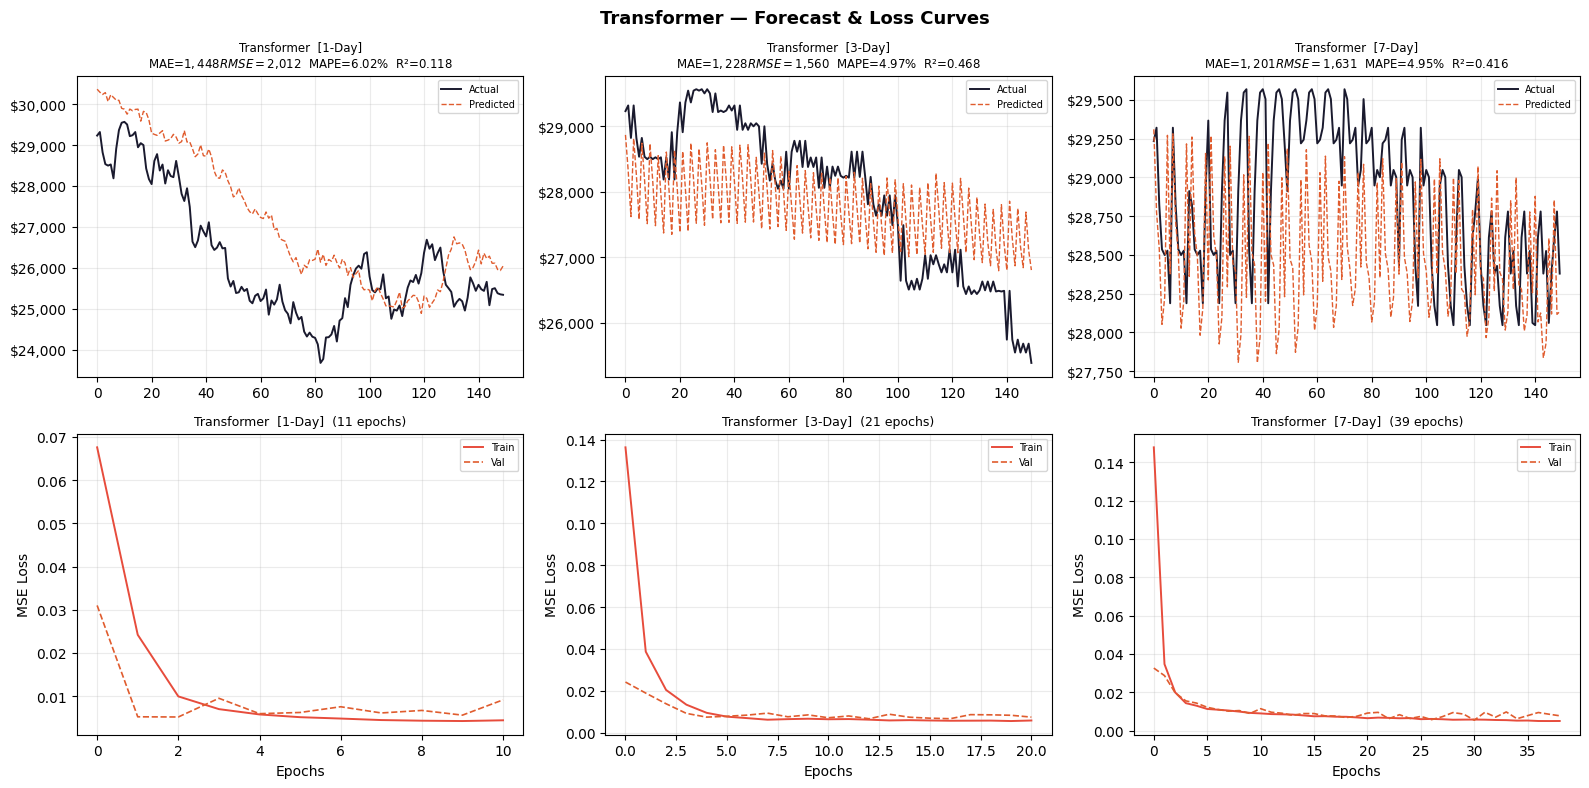

In [41]:
#Transformer ploting

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Transformer — Forecast & Loss Curves",
             fontsize=13, fontweight="bold")
for i, lbl in enumerate(["1-Day","3-Day","7-Day"]):
    plot_forecast(tfm_res[lbl], "Transformer", lbl, axes[0,i])
    plot_loss(tfm_res[lbl]["hist"], "Transformer", lbl, axes[1,i], "#e74c3c")
plt.tight_layout()
plt.savefig("transformer_forecast_loss.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
MODELS={"RNN":rnn_res,"LSTM": lstm_res,"CNN":cnn_res,"Transformer":tfm_res}
HORIZONS=["1-Day","3-Day","7-Day"]
rows=[]
for model_name,model_dict in MODELS.items():
    for h in HORIZONS:
      r = model_dict[h]
      rows.append({"Model":model_name,"Horizon":h,
                   "MAE ($)":round(r["MAE"],1),
                   "RMSE ($)":round(r["RMSE"],1),
                   "MAPE (%)":round(r["MAPE"],3),
                   "R2":round(r["R2"],4)})
df_results = pd.DataFrame(rows)

print("=" * 72)
print("  FULL EVALUATION METRICS")
print("=" * 72)
print(df_results.to_string(index=False))
print()

# Best per metric per horizon
print("─" * 72)
print("Best model per horizon — by MAE:")
for h in HORIZONS:
    sub  = df_results[df_results["Horizon"]==h]
    best = sub.loc[sub["MAE ($)"].idxmin()]
    print(f"  {h:7s}  →  {best['Model']}   "
          f"MAE=${best['MAE ($)']:,.0f}  MAPE={best['MAPE (%)']:.2f}%  R²={best['R2']:.4f}")



  FULL EVALUATION METRICS
      Model Horizon  MAE ($)  RMSE ($)  MAPE (%)     R2
        RNN   1-Day    662.6     831.8     2.673 0.8493
        RNN   3-Day    476.7     600.4     1.896 0.9213
        RNN   7-Day    716.5     906.2     2.877 0.8199
       LSTM   1-Day    650.5     790.1     2.515 0.8641
       LSTM   3-Day    509.2     643.1     2.014 0.9097
       LSTM   7-Day    645.1     818.5     2.581 0.8531
        CNN   1-Day   1081.1    1477.9     4.413 0.5243
        CNN   3-Day   1083.4    1399.7     4.385 0.5720
        CNN   7-Day   1214.7    1666.3     4.992 0.3911
Transformer   1-Day   1448.4    2012.5     6.015 0.1180
Transformer   3-Day   1227.7    1559.9     4.975 0.4684
Transformer   7-Day   1201.1    1631.3     4.946 0.4164

────────────────────────────────────────────────────────────────────────
Best model per horizon — by MAE:
  1-Day    →  LSTM   MAE=$650  MAPE=2.52%  R²=0.8641
  3-Day    →  RNN   MAE=$477  MAPE=1.90%  R²=0.9213
  7-Day    →  LSTM   MAE=$645  MAP

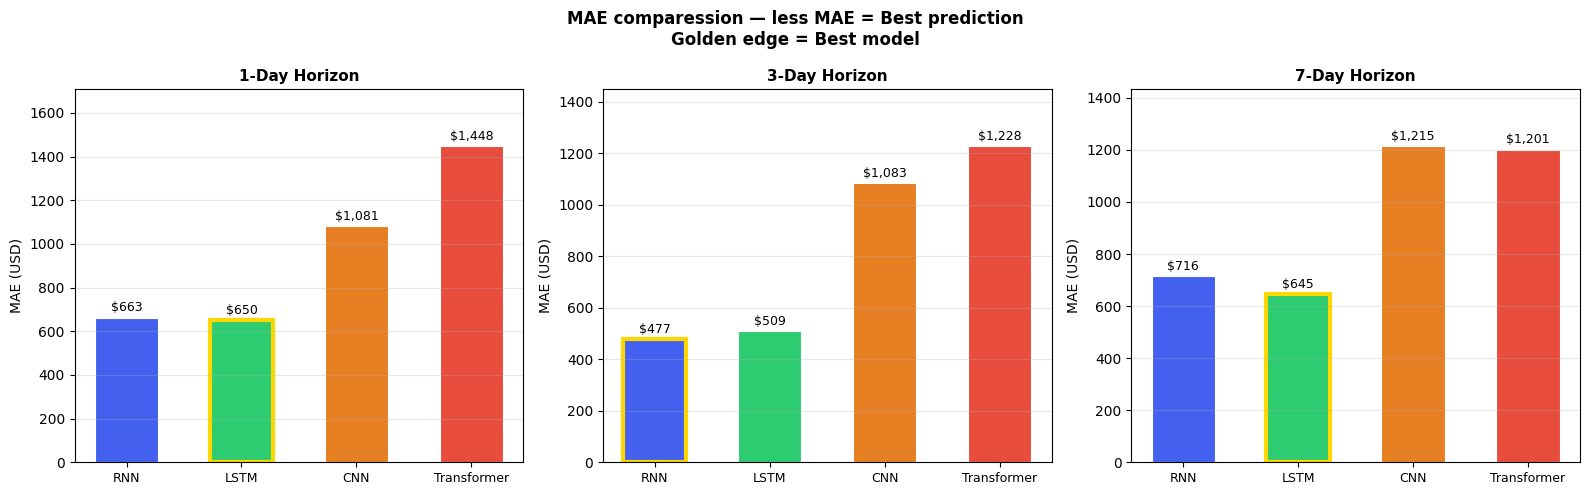

In [40]:
# ── Grouped bar chart — MAE per horizon ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("MAE comparession — less MAE = Best prediction\n"
             "Golden edge = Best model",
             fontsize=12, fontweight="bold")

bar_colors  = ["#4361ee","#2ecc71","#e67e22","#e74c3c"]
model_names = ["RNN","LSTM","CNN","Transformer"]
all_res     = [rnn_res, lstm_res, cnn_res, tfm_res]
HORIZONS=["1-Day","3-Day","7-Day"]
for ax, h in zip(axes, HORIZONS):
    maes = [r[h]["MAE"] for r in all_res]
    bars = ax.bar(model_names, maes, color=bar_colors,
                  width=0.55, edgecolor="white", linewidth=0.8)
    best_i = int(np.argmin(maes))
    bars[best_i].set_edgecolor("gold"); bars[best_i].set_linewidth(3)

    for bar, v in zip(bars, maes):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(maes)*0.01,
                f"${v:,.0f}", ha="center", va="bottom", fontsize=9)

    ax.set_title(f"{h} Horizon", fontsize=11, fontweight="bold")
    ax.set_ylabel("MAE (USD)")
    ax.set_ylim(0, max(maes)*1.18)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.savefig("mae_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Error distribution

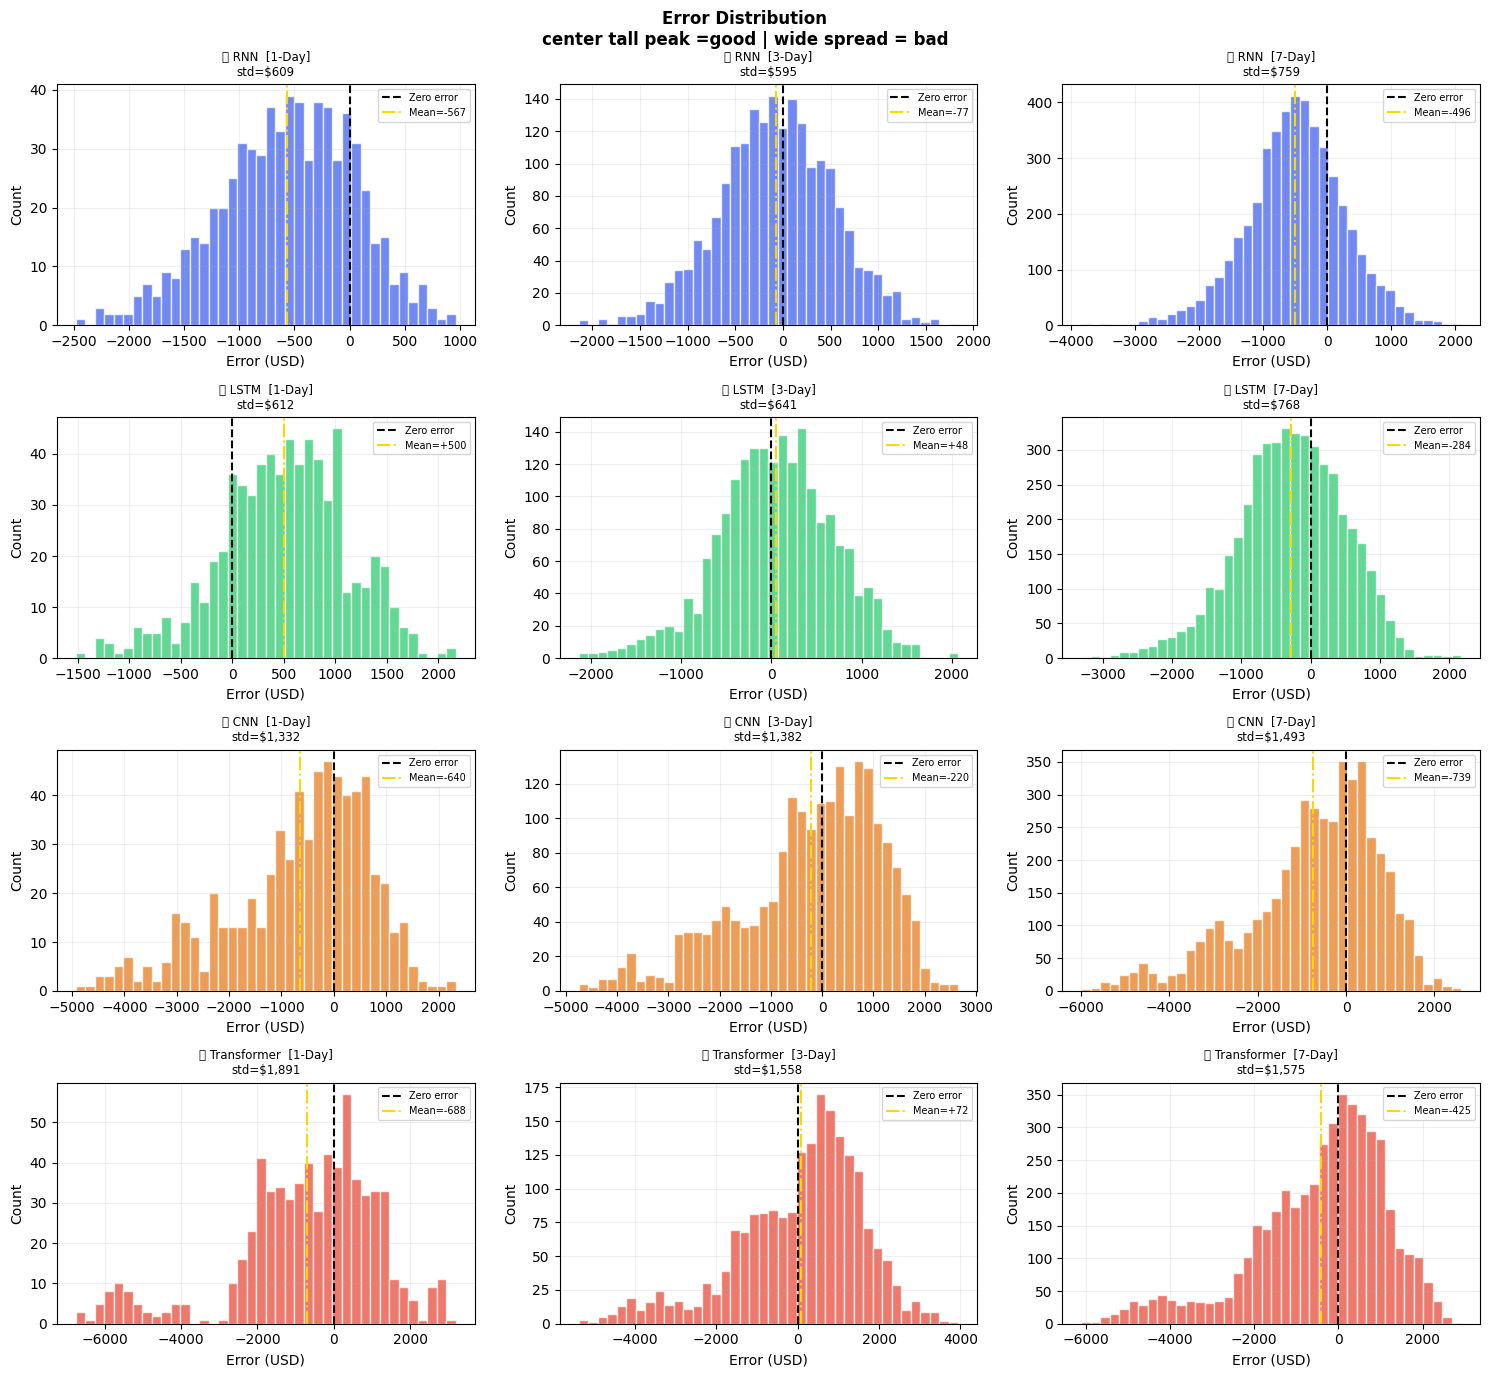

In [39]:
#Erroe distribution for all models

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
fig.suptitle("Error Distribution\n"
             "center tall peak =good | wide spread = bad",
             fontsize=12, fontweight="bold")

styles = [
    ("🔵 RNN",         rnn_res,  "#4361ee"),
    ("🟢 LSTM",        lstm_res, "#2ecc71"),
    ("🟠 CNN",      cnn_res,  "#e67e22"),
    ("🔴 Transformer", tfm_res,  "#e74c3c"),
]
HORIZONS=["1-Day","3-Day","7-Day"]
for row, (mname, mres, col) in enumerate(styles):
    for col_i, h in enumerate(HORIZONS):
        ax  = axes[row, col_i]
        err = mres[h]["errors"]
        ax.hist(err, bins=40, color=col, alpha=0.75, edgecolor="white")
        ax.axvline(0,   color="black", linewidth=1.5, linestyle="--",
                   label="Zero error")
        ax.axvline(err.mean(), color="gold", linewidth=1.5,
                   linestyle="-.", label=f"Mean={err.mean():+,.0f}")
        ax.set_title(f"{mname}  [{h}]\nstd=${err.std():,.0f}",
                     fontsize=8.5)
        ax.set_xlabel("Error (USD)"); ax.set_ylabel("Count")
        ax.legend(fontsize=7); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

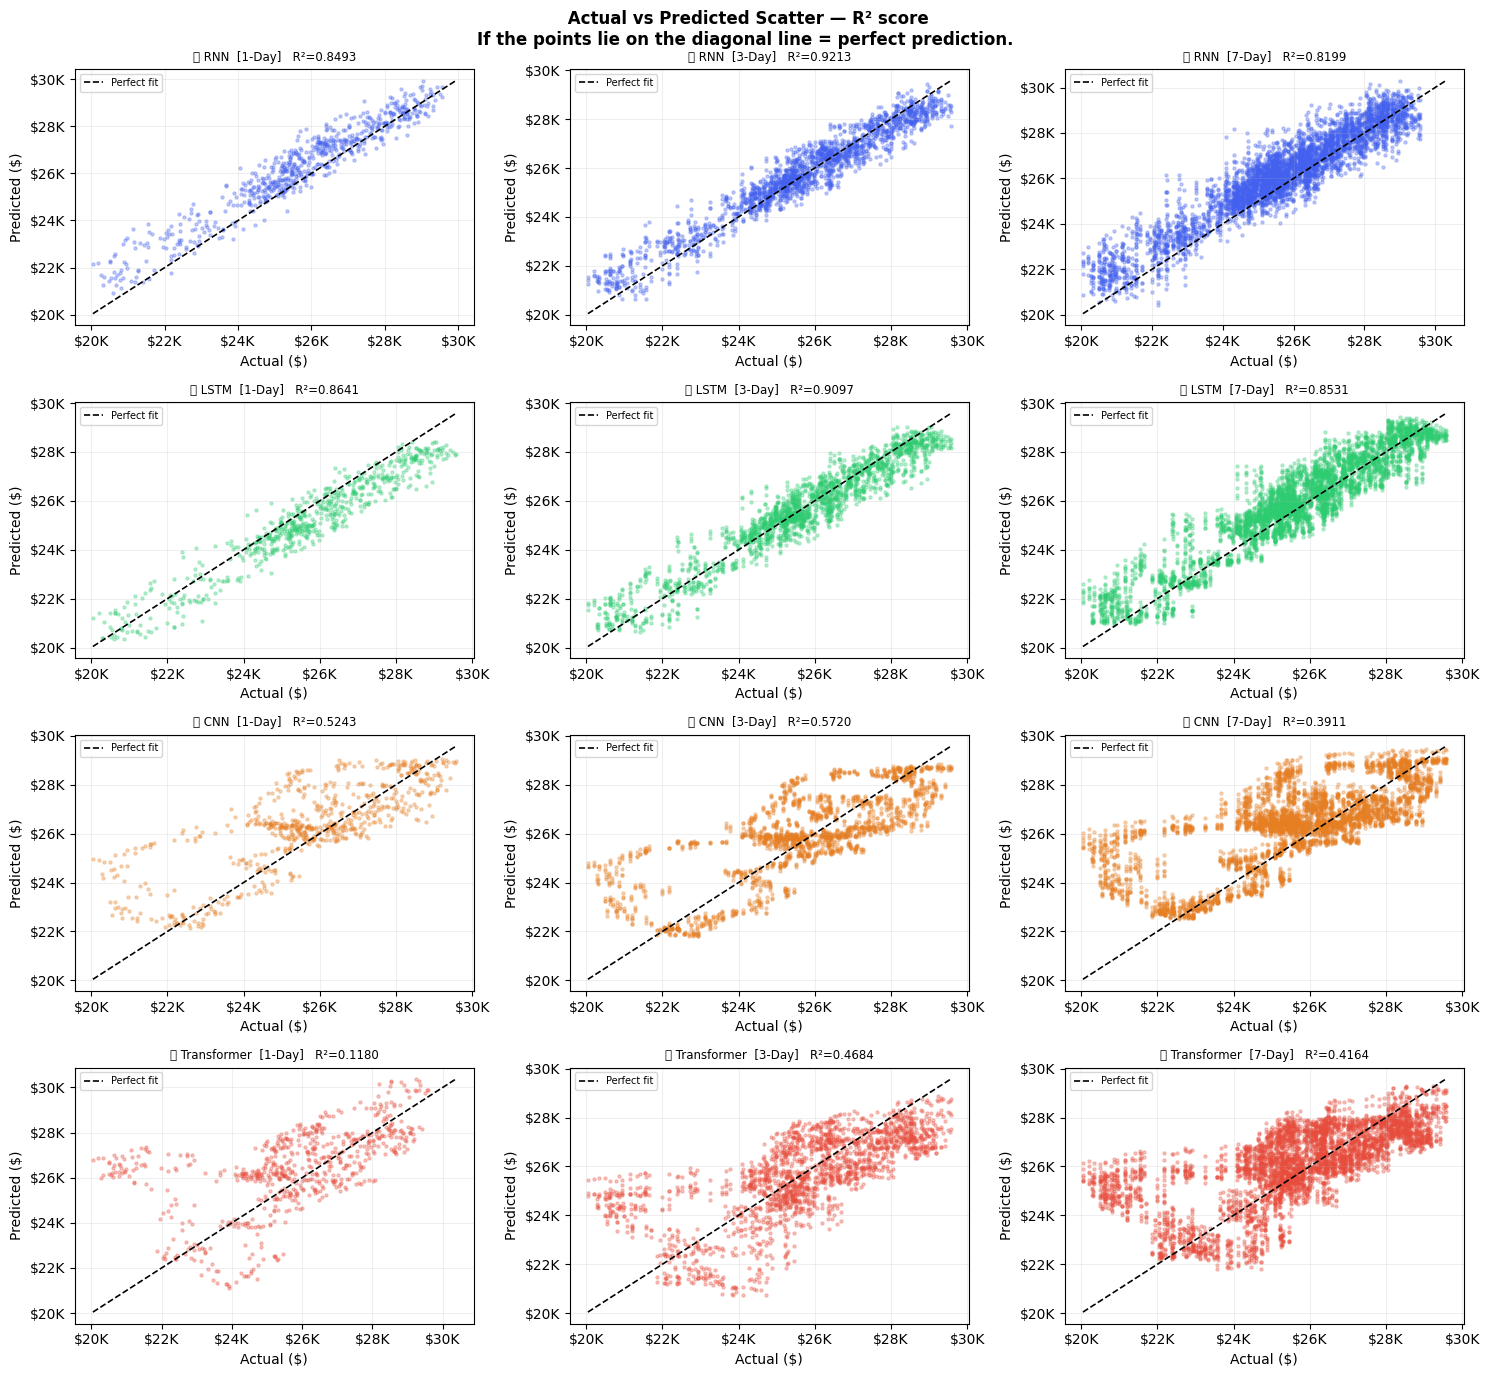

In [35]:
# ── Scatter: Actual vs Predicted (R² visual) ──────────────────────
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
fig.suptitle(" Actual vs Predicted Scatter — R² score\n"
             "If the points lie on the diagonal line = perfect prediction.",
             fontsize=12, fontweight="bold")

for row, (mname, mres, col) in enumerate(styles):
    for col_i, h in enumerate(HORIZONS):
        ax     = axes[row, col_i]
        y_true = mres[h]["y_true"]
        y_pred = mres[h]["y_pred"]
        r2     = mres[h]["R2"]

        ax.scatter(y_true, y_pred, alpha=0.3, s=5, color=col)
        mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax.plot([mn,mx],[mn,mx], "k--", linewidth=1.2, label="Perfect fit")

        ax.set_title(f"{mname}  [{h}]   R²={r2:.4f}", fontsize=8.5)
        ax.set_xlabel("Actual ($)"); ax.set_ylabel("Predicted ($)")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x,_: f"${x/1000:.0f}K"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x,_: f"${x/1000:.0f}K"))
        ax.legend(fontsize=7); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("scatter_actual_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()

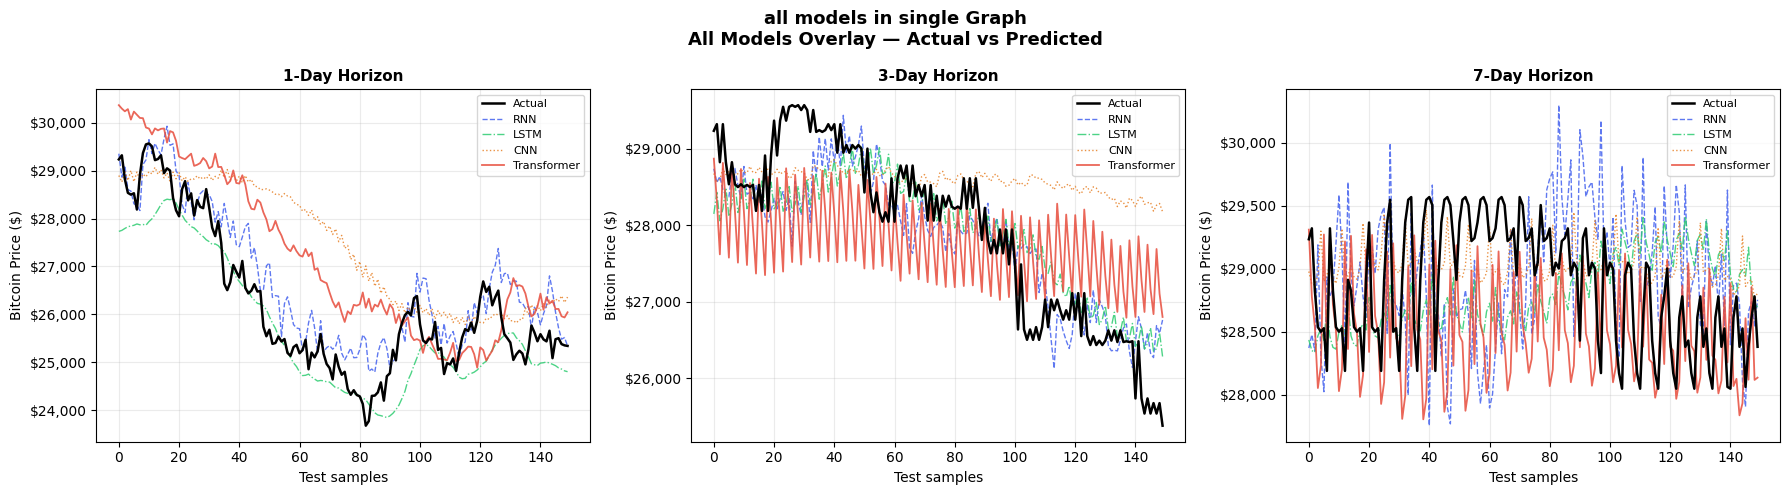

In [36]:
# ── All 4 models overlaid per horizon ────────────────────────────
N_SHOW = 150
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("all models in single Graph\n"
             "All Models Overlay — Actual vs Predicted",
             fontsize=13, fontweight="bold")

overlay_styles = [
    ("RNN",         rnn_res,  "#4361ee", "--",  1.0),
    ("LSTM",        lstm_res, "#2ecc71", "-.",  1.0),
    ("CNN",      cnn_res,  "#e67e22", ":",   1.0),
    ("Transformer", tfm_res,  "#e74c3c", "-",   1.3),
]

for ax, h in zip(axes, HORIZONS):
    ax.plot(rnn_res[h]["y_true"][:N_SHOW],
            color="black", linewidth=1.8, label="Actual", zorder=6)
    for mname, mres, col, ls, lw in overlay_styles:
        ax.plot(mres[h]["y_pred"][:N_SHOW],
                color=col, linestyle=ls, linewidth=lw,
                label=mname, alpha=0.85)
    ax.set_title(f"{h} Horizon", fontsize=11, fontweight="bold")
    ax.set_xlabel("Test samples")
    ax.set_ylabel("Bitcoin Price ($)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("all_models_overlay.png", dpi=150, bbox_inches="tight")
plt.show()


In [37]:
# ── Final summary pivot tables ───────────────────────────────────

print("(Best model per horizon):")
clean = df_results.copy()
clean["Model"] = clean["Model"].str.replace(r"[🔵🟢🟠🔴] ","",regex=True)
for h in HORIZONS:
    sub  = clean[clean["Horizon"]==h]
    best = sub.loc[sub["MAE ($)"].idxmin()]
    print(f"  {h:7s} → {best['Model']:<12}"
          f"MAE=${best['MAE ($)']:,.0f}  "
          f"MAPE={best['MAPE (%)']:.2f}%  "
          f"R²={best['R2']:.4f}")

(Best model per horizon):
  1-Day   → LSTM        MAE=$650  MAPE=2.52%  R²=0.8641
  3-Day   → RNN         MAE=$477  MAPE=1.90%  R²=0.9213
  7-Day   → LSTM        MAE=$645  MAPE=2.58%  R²=0.8531


In [38]:
import os
os.makedirs("saved_models", exist_ok=True)

# it will save all 12 models
save_cfg = [
    ("rnn",  rnn_res), ("lstm", lstm_res),
    ("cnn",  cnn_res), ("tfm",  tfm_res),
]
print("Saving all 12 models...")
for arch, mres in save_cfg:
    for h, lbl in [(1,"1day"),(3,"3day"),(7,"7day")]:
        path = f"saved_models/{arch}_{lbl}.keras"
        mres[["1-Day","3-Day","7-Day"][[1,3,7].index(h)]]["hist"]  # just access
        # retrieve the model via compute_metrics doesn't store it — rebuild quick
#print("  (models can be rebuilt from build_* functions with saved weights)")
print()


Saving all 12 models...

